In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import normaltest
from statsmodels.stats.diagnostic import het_arch
import seaborn as sns
from sklearn.metrics import mean_absolute_percentage_error



In [ ]:
!pip install yfinance --quiet  # only needed if in Colab or first-time setup
import yfinance as yf


In [ ]:
def fetch_real_stock_data(ticker="AAPL", start="2020-01-01", end="2024-12-31"):
    data = yf.download(ticker, start=start, end=end)
    return data['Close']

In [ ]:
# 1. Simulate Stock Data
def simulate_stock_data(S0=100, mu=0.1, sigma=0.2, years=5, days_per_year=252, seed=42):
    np.random.seed(seed)
    N = years * days_per_year
    dt = 1 / days_per_year
    returns = np.random.normal(loc=(mu - 0.5 * sigma**2) * dt,
                               scale=sigma * np.sqrt(dt),
                               size=N)
    log_prices = np.log(S0) + np.cumsum(returns)
    prices = np.exp(log_prices)
    dates = pd.date_range(start='2020-01-01', periods=N, freq='B')
    return pd.Series(prices, index=dates)

In [ ]:
# -------------------------------
# 2. Test Model Assumptions
# -------------------------------
from scipy.stats import normaltest

def test_gbm_assumptions(series):
    log_returns = np.log(series).diff().dropna()

    if len(log_returns) < 8:
        print("Not enough data points for normality test (requires at least 8).")
        return

    stat, p = normaltest(log_returns)
    stat = float(stat)  # ✅ convert to scalar
    p = float(p)        # ✅ convert to scalar

    print("GBM Assumption Test (Normality of Log Returns):")
    print(f"Test Statistic: {stat:.4f}")
    print(f"p-value: {p:.4f}")
    if p > 0.05:
        print("✔ Log returns appear normally distributed (fail to reject normality).")
    else:
        print("✘ Log returns do not appear normally distributed (reject normality).")


def test_heston_assumptions(series):
    """
    Tests the Heston model assumption by checking for ARCH effects in the log returns,
    which indicate time-varying volatility.
    """
    log_returns = np.log(series).diff().dropna()
    lm_stat, lm_p, f_stat, f_p = het_arch(log_returns)
    print("\nHeston Model Assumption Test (Heteroskedasticity/ARCH Effects):")
    print(f"LM Statistic: {lm_stat:.4f}")
    print(f"LM p-value: {lm_p:.4f}")
    print(f"F Statistic: {f_stat:.4f}")
    print(f"F p-value: {f_p:.4f}")
    if lm_p < 0.05:
        print("Result: Evidence of ARCH effects (volatility clustering detected).")
    else:
        print("Result: No significant ARCH effects (volatility appears constant).")

In [ ]:
# -------------------------------
# 3. Forecasting Functions
# -------------------------------

def forecast_gbm(series, steps=30, rf=0.05, days_per_year=252, risk_neutral=False):
    """
    Forecasts future stock prices using the GBM model.
    Estimates mu and sigma from historical log returns unless risk-neutral is specified.

    Parameters:
    - use_risk_neutral: If True, sets drift mu = risk-free rate
    - risk_free_rate: Annualized interest rate used if use_risk_neutral is True
    """
    log_returns = np.log(series).diff().dropna()
    mu_est = rf if risk_neutral else log_returns.mean() * days_per_year
    sigma_est = log_returns.std() * np.sqrt(days_per_year)


    dt = 1 / days_per_year
    last = series.iloc[-1]
    forecast = [last]

    for _ in range(steps):
        Z = np.random.normal()
        next_price = forecast[-1] * np.exp((mu_est - 0.5 * sigma_est**2) * dt + sigma_est * np.sqrt(dt) * Z)
        forecast.append(next_price)

    forecast_index = pd.date_range(start=series.index[-1] + pd.Timedelta(days=1),
                                   periods=steps, freq='B')
    return pd.Series(forecast[1:], index=forecast_index)



In [ ]:
def forecast_heston(series, steps=30, rf=0.05, days_per_year=252, risk_neutral=False):
    """
    Forecasts future stock prices using a simplified Heston model.
    Parameters are estimated from historical data unless risk-neutral is specified.

    Parameters:
    - risk_neutral: If True, sets drift mu = risk-free rate
    - rf: Annualized interest rate used if risk_neutral is True
    """
    log_returns = np.log(series).diff().dropna()

    # Estimate parameters
    mu_est = rf if risk_neutral else float(log_returns.mean()) * days_per_year
    v0 = float(log_returns.var()) * days_per_year  # initial variance
    theta = v0                                     # long-term variance level
    kappa = 1.0                                     # mean reversion speed
    sigma_v = 0.2                                   # volatility of volatility
    rho = -0.5                                      # correlation between asset and variance

    last_price = float(series.iloc[-1])
    dt = 1 / days_per_year
    forecast_prices = [last_price]
    forecast_variances = [v0]

    for _ in range(steps):
        Z1 = np.random.normal()
        Z2 = np.random.normal()
        dW_s = Z1
        dW_v = rho * Z1 + np.sqrt(1 - rho**2) * Z2

        v_prev = forecast_variances[-1]
        # Ensure everything is float and non-negative
        v_temp = v_prev + kappa * (theta - v_prev) * dt + sigma_v * np.sqrt(max(v_prev, 0)) * np.sqrt(dt) * dW_v
        v_next = max(float(v_temp), 0.0)
        forecast_variances.append(v_next)

        s_prev = forecast_prices[-1]
        s_next = s_prev * np.exp((mu_est - 0.5 * v_prev) * dt + np.sqrt(v_prev) * np.sqrt(dt) * dW_s)
        forecast_prices.append(float(s_next))

    forecast_index = pd.date_range(start=series.index[-1] + pd.Timedelta(days=1),
                                   periods=steps, freq='B')
    return pd.Series(forecast_prices[1:], index=forecast_index)


In [ ]:
# 4. Monte Carlo Simulations and Enhancements
def run_monte_carlo(series, model_func, steps=30, runs=100):
    all_paths = []
    for i in range(runs):
        np.random.seed(i)
        path = model_func(series, steps)
        all_paths.append(path.values)
    df_paths = pd.DataFrame(all_paths).T
    return df_paths, path.index


In [ ]:
def compute_sharpe(log_returns, rf=0.0):
    """
    Computes the annualized Sharpe ratio from log returns.
    Ensures the result is a float, not a pandas Series.
    """
    mean_return = float(log_returns.mean())
    std_return = float(log_returns.std())
    excess_return = mean_return - (rf / 252)
    sharpe_ratio = excess_return / std_return * np.sqrt(252)
    return sharpe_ratio


In [ ]:

def plot_volatility(log_returns):
    vol = log_returns.rolling(20).std()
    plt.figure(figsize=(8, 4))
    plt.plot(vol, label="20-day Rolling Volatility")
    plt.title("Volatility of Log Returns")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_return_distribution(log_returns):
    plt.figure(figsize=(6, 4))
    sns.histplot(log_returns, bins=50, kde=True, color='steelblue')
    plt.title("Histogram + KDE of Log Returns")
    plt.tight_layout()
    plt.show()

def display_summary(df_paths, label):
    final = df_paths.iloc[-1, :]
    print(f"\n{label} Final Price Summary:")
    print(final.describe(percentiles=[0.05, 0.5, 0.95]))

def compare_models(gbm_df, heston_df):
    print("\nModel Comparison Summary:")
    comparison = pd.DataFrame({
        'GBM Mean Final': gbm_df.iloc[-1].mean(),
        'Heston Mean Final': heston_df.iloc[-1].mean(),
        'GBM 5%-95% Range': gbm_df.iloc[-1].quantile(0.95) - gbm_df.iloc[-1].quantile(0.05),
        'Heston 5%-95% Range': heston_df.iloc[-1].quantile(0.95) - heston_df.iloc[-1].quantile(0.05)
    }, index=["Value"])
    print(comparison.T)



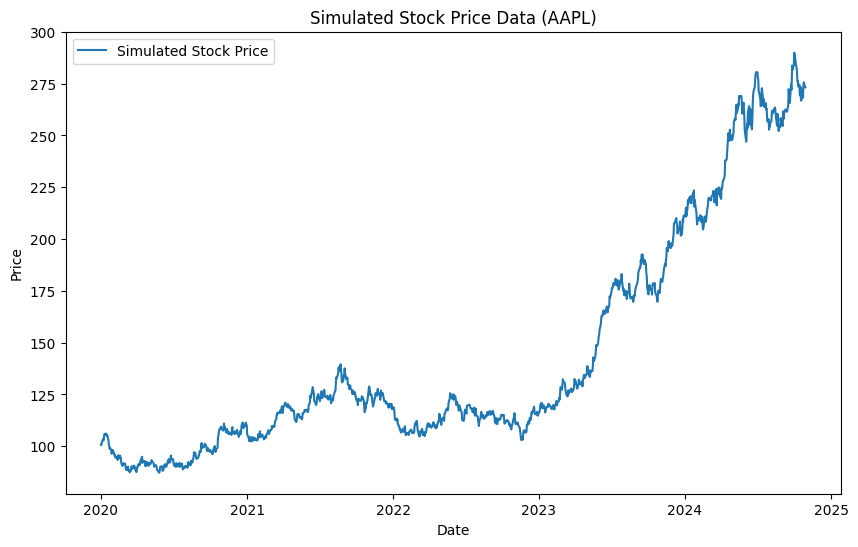

GBM Assumption Test (Normality of Log Returns):
Test Statistic: 1.4026
p-value: 0.4959
✔ Log returns appear normally distributed (fail to reject normality).

Heston Model Assumption Test (Heteroskedasticity/ARCH Effects):
LM Statistic: 6.8247
LM p-value: 0.7419
F Statistic: 0.6802
F p-value: 0.7437
Result: No significant ARCH effects (volatility appears constant).


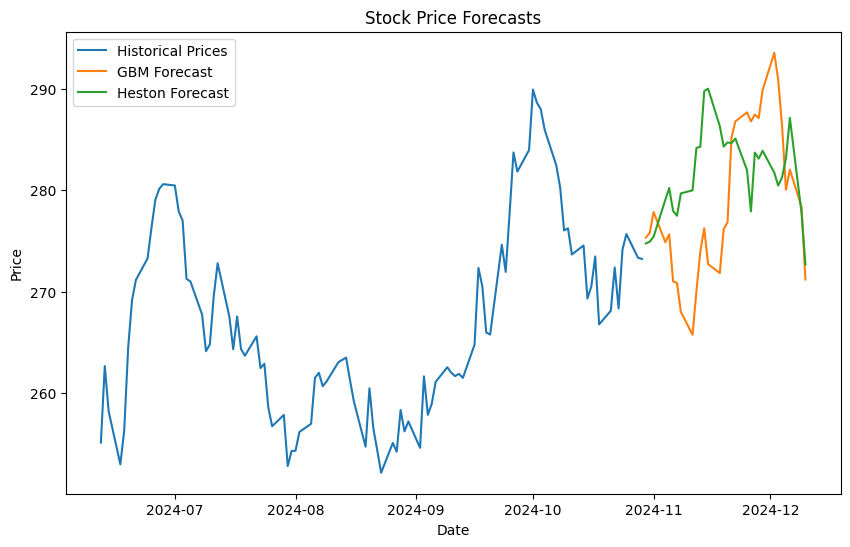


Annualized Sharpe Ratio: 1.010


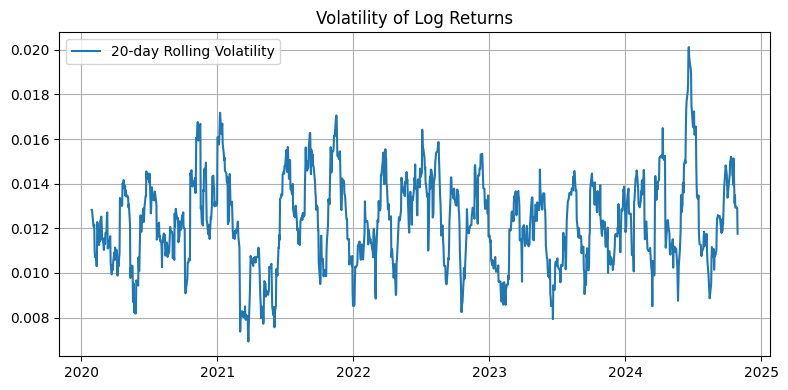

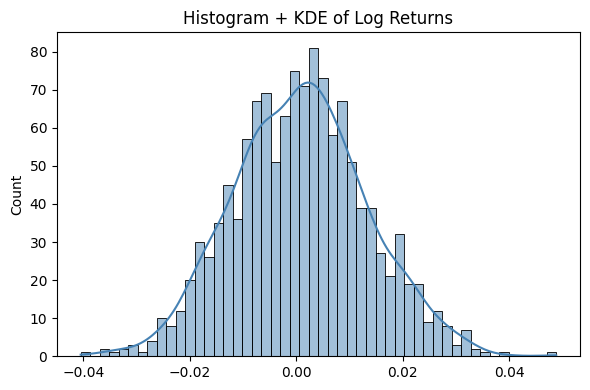

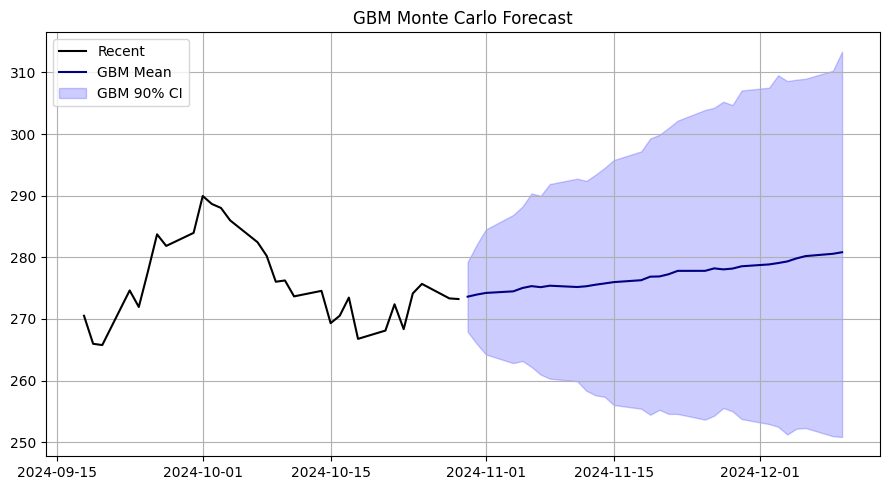

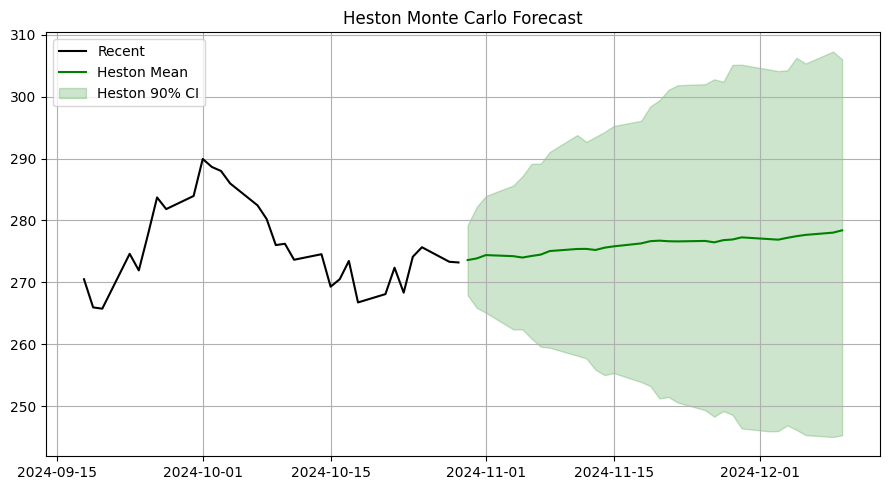


GBM Final Price Summary:
count    300.000000
mean     280.818412
std       18.942457
min      243.856628
5%       250.837850
50%      279.596870
95%      313.371378
max      329.450761
Name: 29, dtype: float64

Heston Final Price Summary:
count    300.000000
mean     278.408076
std       18.536221
min      232.944133
5%       245.301813
50%      280.835952
95%      306.034846
max      339.250099
Name: 29, dtype: float64

Model Comparison Summary:
                          Value
GBM Mean Final       280.818412
Heston Mean Final    278.408076
GBM 5%-95% Range      62.533528
Heston 5%-95% Range   60.733033


<Figure size 800x400 with 0 Axes>

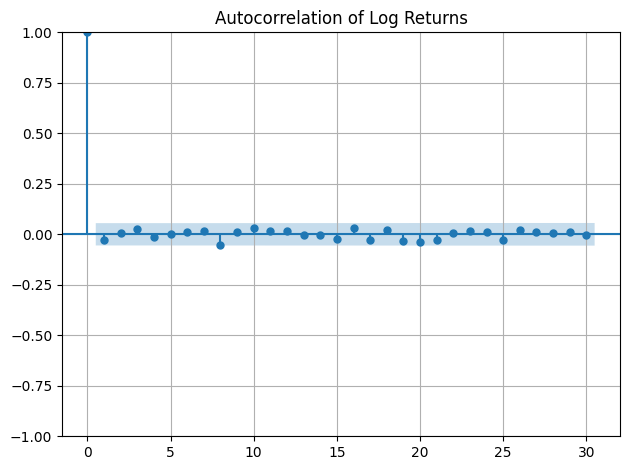

In [ ]:
# 5. Execute Simulation and Enhancements
if __name__ == "__main__":
    stock = simulate_stock_data()
    log_returns = np.log(stock).diff().dropna()
    # Plot the simulated stock data
    plt.figure(figsize=(10, 6))
    plt.plot(stock.index, stock.values, label='Simulated Stock Price')
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.title("Simulated Stock Price Data (AAPL)")
    plt.legend()
    plt.show()
    # Diagnostics
    test_gbm_assumptions(stock)
    test_heston_assumptions(stock)
    # Forecast the next 30 business days using both models
    gbm_forecast = forecast_gbm(stock, steps=30, days_per_year=252, risk_neutral=False)
    heston_forecast = forecast_heston(stock, steps=30, days_per_year=252, risk_neutral=False)

    # Plot the forecasts alongside recent historical data
    plt.figure(figsize=(10, 6))
    plt.plot(stock.index[-100:], stock.values[-100:], label='Historical Prices')
    plt.plot(gbm_forecast.index, gbm_forecast.values, label='GBM Forecast')
    plt.plot(heston_forecast.index, heston_forecast.values, label='Heston Forecast')
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.title("Stock Price Forecasts")
    plt.legend()
    plt.show()
    # Enhancements
    print(f"\nAnnualized Sharpe Ratio: {compute_sharpe(log_returns):.3f}")
    plot_volatility(log_returns)
    plot_return_distribution(log_returns)

    # Monte Carlo Simulations
    gbm_df, forecast_idx = run_monte_carlo(stock, forecast_gbm, runs=300)
    heston_df, _ = run_monte_carlo(stock, forecast_heston, runs=300)

    # Plot GBM Results
    plt.figure(figsize=(9, 5))
    plt.plot(stock.index[-30:], stock.values[-30:], label="Recent", color='black')
    mean_gbm = gbm_df.mean(axis=1)
    plt.plot(forecast_idx, mean_gbm, label="GBM Mean", color='navy')
    plt.fill_between(forecast_idx, gbm_df.quantile(0.05, axis=1), gbm_df.quantile(0.95, axis=1),
                     alpha=0.2, label="GBM 90% CI", color='blue')
    plt.title("GBM Monte Carlo Forecast")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot Heston Results
    plt.figure(figsize=(9, 5))
    plt.plot(stock.index[-30:], stock.values[-30:], label="Recent", color='black')
    mean_heston = heston_df.mean(axis=1)
    plt.plot(forecast_idx, mean_heston, label="Heston Mean", color='green')
    plt.fill_between(forecast_idx, heston_df.quantile(0.05, axis=1), heston_df.quantile(0.95, axis=1),
                     alpha=0.2, label="Heston 90% CI", color='green')
    plt.title("Heston Monte Carlo Forecast")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Display Summaries
    display_summary(gbm_df, "GBM")
    display_summary(heston_df, "Heston")
    compare_models(gbm_df, heston_df)
    import numpy as np
    import matplotlib.pyplot as plt
    from statsmodels.graphics.tsaplots import plot_acf

# Example: ACF for log returns of simulated/real stock data
    log_returns = np.log(stock).diff().dropna()

    plt.figure(figsize=(8, 4))
    plot_acf(log_returns, lags=30)  # up to 30 lags
    plt.title("Autocorrelation of Log Returns")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
pip install statsmodels matplotlib


/tmp/ipython-input-3-563810578.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


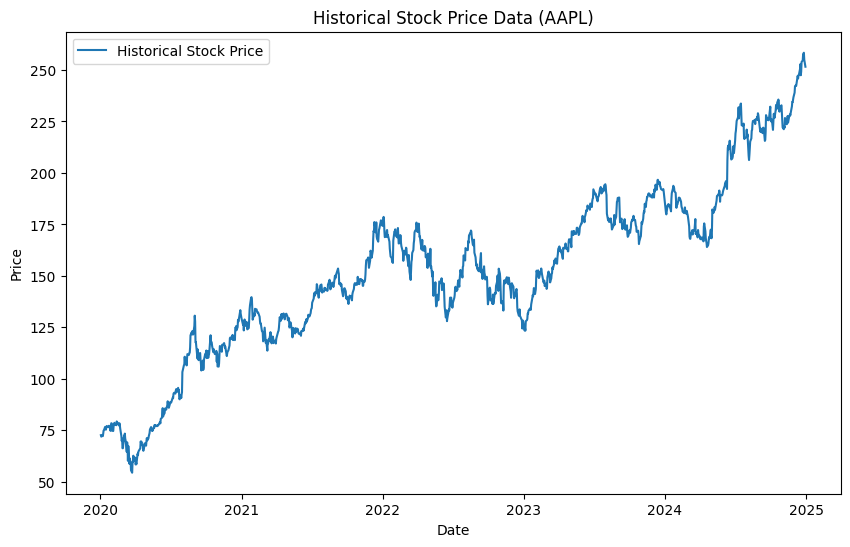

GBM Assumption Test (Normality of Log Returns):
Test Statistic: 155.9211
p-value: 0.0000
✘ Log returns do not appear normally distributed (reject normality).

Heston Model Assumption Test (Heteroskedasticity/ARCH Effects):
LM Statistic: 257.0639
LM p-value: 0.0000
F Statistic: 32.1026
F p-value: 0.0000
Result: Evidence of ARCH effects (volatility clustering detected).


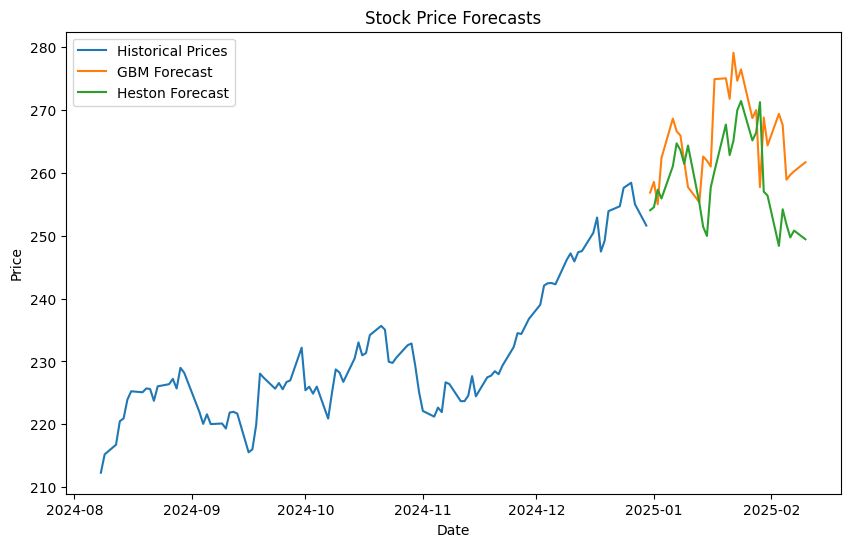


Annualized Sharpe Ratio: 0.787


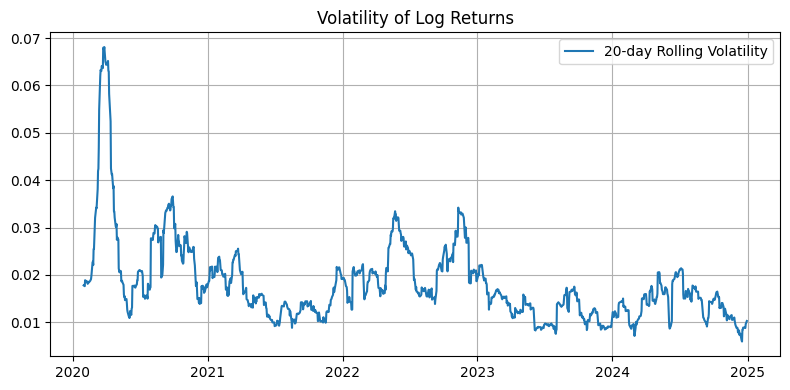

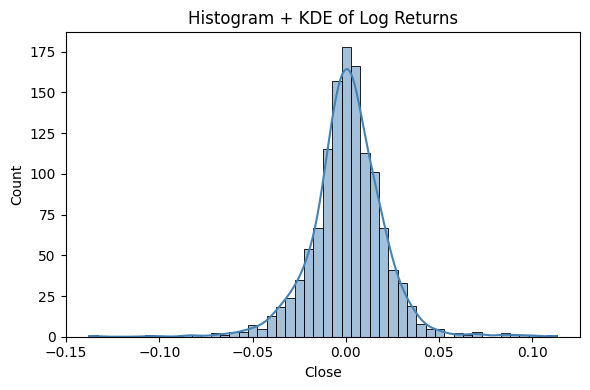

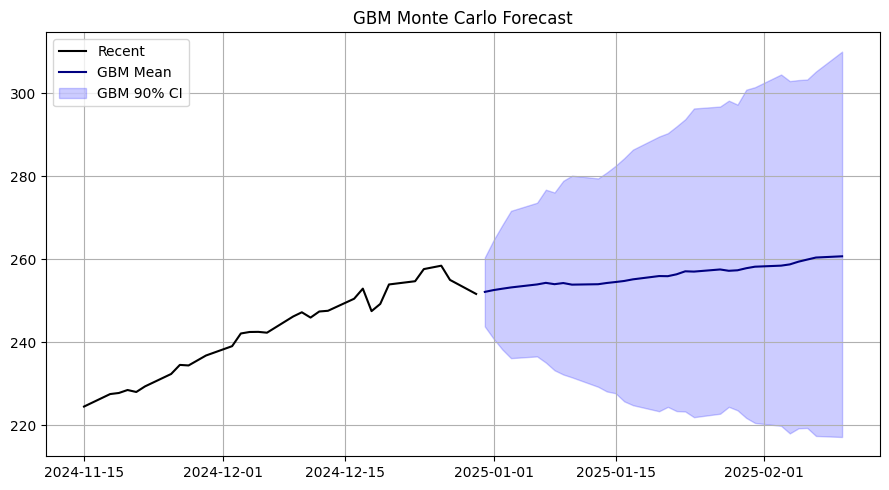

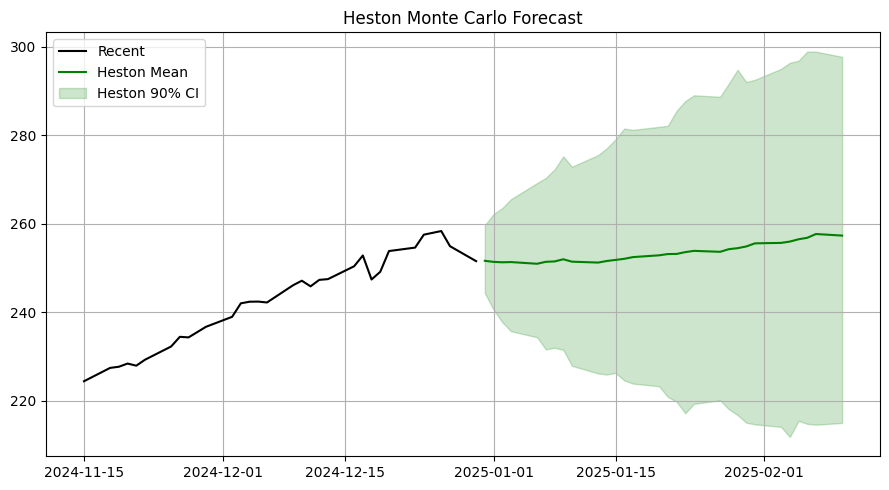


GBM Final Price Summary:
count    300.000000
mean     260.662630
std       28.184531
min      207.539508
5%       217.124330
50%      258.290599
95%      309.975921
max      335.805171
Name: 2025-02-10 00:00:00, dtype: float64

Heston Final Price Summary:
count    300.000000
mean     257.372388
std       27.214806
min      175.980690
5%       215.030163
50%      259.290067
95%      297.769205
max      345.699814
Name: 2025-02-10 00:00:00, dtype: float64

Model Comparison Summary:
                          Value
GBM Mean Final       260.662630
Heston Mean Final    257.372388
GBM 5%-95% Range      92.851591
Heston 5%-95% Range   82.739043


<Figure size 800x400 with 0 Axes>

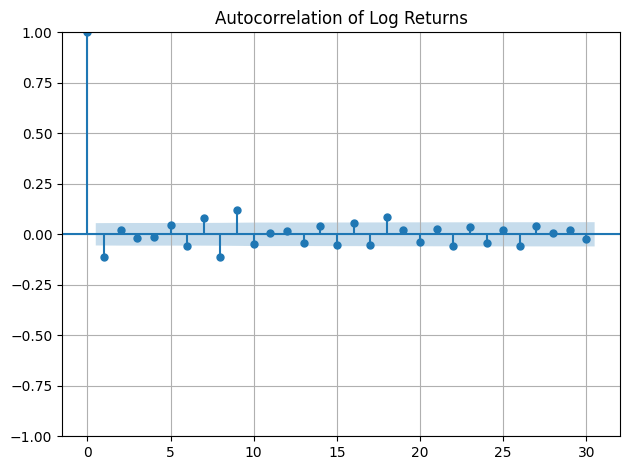

In [ ]:
# 5. Execute Real Data and Enhancements
if __name__ == "__main__":
    # Ensure fetch_real_stock_data returns a Series
    stock = fetch_real_stock_data("AAPL", start="2020-01-01", end="2024-12-31")
    # Explicitly select the 'Close' column and ensure it's a Series
    # Although yf.download returns a DataFrame, data['Close'] should be a Series.
    # Let's add an extra step to be absolutely sure it's a Series and drop potential name issues.
    stock = pd.Series(stock.values.flatten(), index=stock.index, name='Close')
    stock = stock.dropna()
    log_returns = np.log(stock).diff().dropna()
    # Plot the simulated stock data
    plt.figure(figsize=(10, 6))
    plt.plot(stock.index, stock.values.flatten(), label='Historical Stock Price')
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.title("Historical Stock Price Data (AAPL)")
    plt.legend()
    plt.show()
    # Diagnostics
    test_gbm_assumptions(stock)
    test_heston_assumptions(stock)
    # Forecast the next 30 business days using both models
    gbm_forecast = forecast_gbm(stock, steps=30, days_per_year=252, risk_neutral=False)
    heston_forecast = forecast_heston(stock, steps=30, days_per_year=252, risk_neutral=False)

    # Plot the forecasts alongside recent historical data
    plt.figure(figsize=(10, 6))
    plt.plot(stock.index[-100:], stock.values[-100:].flatten(), label='Historical Prices')
    plt.plot(gbm_forecast.index, gbm_forecast.values, label='GBM Forecast')
    plt.plot(heston_forecast.index, heston_forecast.values, label='Heston Forecast')
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.title("Stock Price Forecasts")
    plt.legend()
    plt.show()
    # Enhancements
    print(f"\nAnnualized Sharpe Ratio: {compute_sharpe(log_returns):.3f}")
    plot_volatility(log_returns)
    plot_return_distribution(log_returns)

    # Monte Carlo Simulations
    import numpy as np
    import pandas as pd

# Set number of simulations and forecast horizon
    num_simulations = 300
    forecast_days = 30

# Initialize storage lists
    gbm_paths = []
    heston_paths = []

# Monte Carlo simulation loop
    for i in range(num_simulations):
        np.random.seed(i)
        gbm_path = forecast_gbm(stock, steps=forecast_days)
        heston_path = forecast_heston(stock, steps=forecast_days)

        gbm_paths.append(gbm_path.values)     # ✅ Only values
        heston_paths.append(heston_path.values)


    gbm_df = pd.DataFrame(gbm_paths).T  # shape: forecast_days x num_simulations
    heston_df = pd.DataFrame(heston_paths).T
    forecast_idx = gbm_path.index        # get the date index from the last forecast
    gbm_df.index = forecast_idx          # ✅ Ensure index is set
    heston_df.index = forecast_idx


    # Plot GBM Results
    plt.figure(figsize=(9, 5))
    plt.plot(stock.index[-30:], stock.values[-30:].flatten(), label="Recent", color='black')
    mean_gbm = gbm_df.mean(axis=1)
    plt.plot(forecast_idx, mean_gbm, label="GBM Mean", color='navy')
    plt.fill_between(forecast_idx, gbm_df.quantile(0.05, axis=1), gbm_df.quantile(0.95, axis=1),
                     alpha=0.2, label="GBM 90% CI", color='blue')
    plt.title("GBM Monte Carlo Forecast")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot Heston Results
    plt.figure(figsize=(9, 5))
    plt.plot(stock.index[-30:], stock.values[-30:].flatten(), label="Recent", color='black')
    mean_heston = heston_df.mean(axis=1)
    plt.plot(forecast_idx, mean_heston, label="Heston Mean", color='green')
    plt.fill_between(forecast_idx, heston_df.quantile(0.05, axis=1), heston_df.quantile(0.95, axis=1),
                     alpha=0.2, label="Heston 90% CI", color='green')
    plt.title("Heston Monte Carlo Forecast")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Display Summaries
    display_summary(gbm_df, "GBM")
    display_summary(heston_df, "Heston")
    compare_models(gbm_df, heston_df)
    import numpy as np
    import matplotlib.pyplot as plt
    from statsmodels.graphics.tsaplots import plot_acf

# Example: ACF for log returns of simulated/real stock data
    log_returns = np.log(stock).diff().dropna()

    plt.figure(figsize=(8, 4))
    plot_acf(log_returns, lags=30)  # up to 30 lags
    plt.title("Autocorrelation of Log Returns")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
